In [1]:
# Cell 0 — Kernel environment check（确认当前 notebook 使用的 Python 环境）

import sys
import pybamm
from pathlib import Path

print("Python executable:", sys.executable)
print("PyBaMM version:", pybamm.__version__)
print("Current working directory:", Path.cwd())

Python executable: /Users/louislu/projects/pybamm-aging-bridge/.venv/bin/python
PyBaMM version: 26.3.1
Current working directory: /Users/louislu/projects/pybamm-aging-bridge/notebooks


# Notebook 14 — SEI-only Multi-Checkpoint RPT Fingerprint

## Goal

This notebook performs a multi-checkpoint SEI-only aging fingerprint study.

The goal is to connect SEI-only degradation states to repeated RPT / HPPC diagnostic checkpoints and determine how SEI aging projects into engineering-level observables.

The target diagnostic outputs are:

- SEI thickness growth,
- loss of lithium inventory,
- lithium lost to side reactions,
- side-reaction capacity loss,
- RPT-derived Ri_CD / Ri_EF,
- RPT-derived tau1 / tau2 descriptors.

## Scientific context

Notebook 11 confirmed that the SEI-only model branch is runnable and exposes degradation variables.

Notebook 12 confirmed that short SEI-only cycling produces monotonic SEI / LLI / side-reaction capacity-loss drift.

Notebook 13 confirmed that a SEI-aged state can be continued into an RPT / HPPC checkpoint using `starting_solution`, and that aged-state CDEFG / Ri / tau extraction is technically feasible.

The next question is:

Does SEI-only aging produce a diagnostic fingerprint that is mainly capacity / LLI dominated, Ri dominated, tau dominated, or mixed?

## Checkpoint design

This notebook uses the following SEI-only aging checkpoints:

- 0 cycles
- 3 cycles
- 10 cycles
- 20 cycles

At each checkpoint, a diagnostic RPT / HPPC branch is run.

Important:

The RPT branch is diagnostic only. It must not be used as the starting state for subsequent aging.

The aging trajectory must continue from the pre-RPT aging state.

## RPT / HPPC protocol

Direct SOC-targeted Experiment syntax such as `until 50% SOC` is not supported by PyBaMM Experiment strings.

Therefore, this notebook uses the fallback strategy established in Notebook 13:

- C/3 discharge for 1.5 h,
- rest for 60 s,
- 1C discharge pulse for 10 s,
- rest for 600 s.

This approximates SOC = 50% on a nominal-capacity basis.

## Workflow

1. Import packages and audit project paths.
2. Define SEI-only model configuration.
3. Define checkpoint schedule.
4. Define aging-block protocol.
5. Define RPT / HPPC diagnostic protocol.
6. Run checkpoint 0 RPT.
7. Run sequential SEI-only aging blocks.
8. At each checkpoint, branch into RPT / HPPC diagnostics.
9. Extract degradation-state variables before each RPT.
10. Extract CDEFG, Ri, and tau descriptors from each RPT.
11. Build multi-checkpoint fingerprint tables.
12. Plot degradation-state drift and RPT observable drift.

## Expected outputs

- `data/sei_multi_checkpoint_degradation_state_table.csv`
- `data/sei_multi_checkpoint_rpt_observable_table.csv`
- `data/sei_multi_checkpoint_fingerprint_drift_table.csv`
- SEI / LLI / capacity-loss drift plots
- Ri / tau RPT drift plots

## Interpretation boundary

This notebook does not establish a validated SEI aging law or real-cell SOH trajectory.

The current cycling protocol is a proof-of-concept simulation protocol.

The RPT conditioning is nominal-capacity based and approximate, not a strict aged-cell true-SOC control.

The correct conclusion format is:

“Under this SEI-only proof-of-concept protocol, the selected degradation variables and RPT observables drift in the following pattern.”

In [2]:
# Cell 2 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [3]:
# Cell 3 — SEI-only model configuration（SEI-only 模型配置）

PARAMETER_SET = "OKane2022"
SEI_OPTION = "solvent-diffusion limited"

SEI_ONLY_OPTIONS = {
    "SEI": SEI_OPTION,
    "lithium plating": "none",
    "loss of active material": "none",
    "particle mechanics": "none",
    "SEI porosity change": "false",
}

param = pybamm.ParameterValues(PARAMETER_SET)
model = pybamm.lithium_ion.DFN(SEI_ONLY_OPTIONS)

print("Parameter set:", PARAMETER_SET)
print("SEI option:", SEI_OPTION)
print("Model options:", SEI_ONLY_OPTIONS)

Parameter set: OKane2022
SEI option: solvent-diffusion limited
Model options: {'SEI': ('solvent-diffusion limited', 'none'), 'lithium plating': 'none', 'loss of active material': 'none', 'particle mechanics': 'none', 'SEI porosity change': 'false'}


In [4]:
# Cell 4 — Checkpoint and protocol configuration（checkpoint 与协议配置）

CHECKPOINT_CYCLES = [0, 3, 10, 20]

AGING_OUTPUT_PERIOD = "120 seconds"
RPT_OUTPUT_PERIOD = "0.1 seconds"

AGING_CYCLE_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

RPT_CONDITIONING_STRATEGY = "time_based_approx_50soc"

RPT_HPPC_STEPS = [
    "Discharge at C/3 for 1.5 hours",
    "Rest for 60 seconds",
    "Discharge at 1C for 10 seconds",
    "Rest for 600 seconds",
]

print("Checkpoints:", CHECKPOINT_CYCLES)
print("Aging output period:", AGING_OUTPUT_PERIOD)
print("RPT output period:", RPT_OUTPUT_PERIOD)
print("RPT conditioning strategy:", RPT_CONDITIONING_STRATEGY)

print("\nAging cycle steps:")
for i, step in enumerate(AGING_CYCLE_STEPS, start=1):
    print(f"{i}. {step}")

print("\nRPT/HPPC steps:")
for i, step in enumerate(RPT_HPPC_STEPS, start=1):
    print(f"{i}. {step}")

Checkpoints: [0, 3, 10, 20]
Aging output period: 120 seconds
RPT output period: 0.1 seconds
RPT conditioning strategy: time_based_approx_50soc

Aging cycle steps:
1. Discharge at C/3 until 2.5 V
2. Rest for 10 minutes
3. Charge at C/3 until 4.2 V
4. Hold at 4.2 V until C/100
5. Rest for 10 minutes

RPT/HPPC steps:
1. Discharge at C/3 for 1.5 hours
2. Rest for 60 seconds
3. Discharge at 1C for 10 seconds
4. Rest for 600 seconds


In [5]:
# Cell 5 — Degradation variable selection（选择 SEI / LLI / capacity 老化变量）

degradation_variable_candidates = {
    "sei_thickness_m": [
        "X-averaged negative SEI thickness [m]",
        "X-averaged SEI thickness [m]",
        "Negative SEI thickness [m]",
    ],
    "loss_lithium_inventory_pct": [
        "Loss of lithium inventory [%]",
    ],
    "total_lithium_lost_mol": [
        "Total lithium lost [mol]",
        "Total lithium lost to side reactions [mol]",
    ],
    "capacity_lost_side_reactions_Ah": [
        "Total capacity lost to side reactions [A.h]",
        "Loss of capacity to negative SEI [A.h]",
        "Loss of capacity to SEI [A.h]",
    ],
    "sei_interfacial_current_A_m2": [
        "X-averaged negative electrode SEI interfacial current density [A.m-2]",
        "X-averaged SEI interfacial current density [A.m-2]",
    ],
}


def first_available_solution_variable(solution, candidates):
    for name in candidates:
        try:
            _ = solution[name].entries
            return name
        except Exception:
            pass
    return None


def get_solution_var_final(solution, candidates):
    selected = first_available_solution_variable(solution, candidates)

    if selected is None:
        return None, np.nan

    values = np.asarray(solution[selected].entries)

    if values.ndim == 1:
        return selected, float(values[-1])

    return selected, float(np.mean(values[..., -1]))


selected_model_variables = {}

for short_name, candidates in degradation_variable_candidates.items():
    selected = None
    for name in candidates:
        if name in model.variables:
            selected = name
            break
    selected_model_variables[short_name] = selected

selected_model_variables

{'sei_thickness_m': 'X-averaged negative SEI thickness [m]',
 'loss_lithium_inventory_pct': 'Loss of lithium inventory [%]',
 'total_lithium_lost_mol': 'Total lithium lost [mol]',
 'capacity_lost_side_reactions_Ah': 'Total capacity lost to side reactions [A.h]',
 'sei_interfacial_current_A_m2': 'X-averaged negative electrode SEI interfacial current density [A.m-2]'}

In [6]:
# Cell 6 — RPT extraction helpers（RPT 的 CDEFG / Ri / tau 提取函数）

def extract_rpt_cdefg_and_ri(df, pulse_threshold_factor=0.8):
    """
    Extract CDEFG / Ri from RPT dataframe.

    The RPT contains a long C/3 conditioning discharge before the HPPC pulse.
    Therefore, this function detects the high-current 1C pulse.
    """
    t = df["rpt_time_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    threshold = pulse_threshold_factor * np.nanmax(np.abs(i))
    pulse_mask = np.abs(i) >= threshold
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No HPPC pulse detected.")

    pulse_start_idx = pulse_indices[0]
    pulse_end_idx = pulse_indices[-1]

    t_start = float(t[pulse_start_idx])
    t_end = float(t[pulse_end_idx])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + 600 - 10) & (t <= t_end + 600)

    windows = {
        "C": C_window,
        "D": D_window,
        "E": E_window,
        "F": F_window,
        "G": G_window,
    }

    points = {}
    for label, mask in windows.items():
        if mask.sum() == 0:
            raise ValueError(f"{label} window has no data points.")

        points[label] = {
            "t_s": float(np.median(t[mask])),
            "U_V": float(np.median(u[mask])),
            "n_points": int(mask.sum()),
        }

    I_C = float(np.median(i[C_window]))
    I_D = float(np.median(i[D_window]))
    I_E = float(np.median(i[E_window]))
    I_F = float(np.median(i[F_window]))

    Ri_CD_mohm = abs((points["D"]["U_V"] - points["C"]["U_V"]) / (I_D - I_C)) * 1000
    Ri_EF_mohm = abs((points["F"]["U_V"] - points["E"]["U_V"]) / (I_F - I_E)) * 1000

    result = {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": points["C"]["U_V"],
        "D_U_V": points["D"]["U_V"],
        "E_U_V": points["E"]["U_V"],
        "F_U_V": points["F"]["U_V"],
        "G_U_V": points["G"]["U_V"],
    }

    return result, points


def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    if len(t_fit) < 20:
        raise ValueError("Not enough relaxation points for biexponential fit.")

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]
    p0 = [0.6 * A_total, 3.0, 0.4 * A_total, 30.0]
    bounds = ([0.0, 0.1, 0.0, 1.0], [1.0, 100.0, 1.0, 1000.0])

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
    r2 = 1 - ss_res / ss_tot
    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000

    return {
        "tau1_s": float(tau1),
        "tau2_s": float(tau2),
        "R2": float(r2),
        "RMSE_mV": float(rmse_mV),
        "fit_t_min_s": fit_t_min,
        "fit_t_max_s": fit_t_max,
        "n_fit_points": int(len(t_fit)),
    }


def extract_rpt_tau(df, cdefg_result):
    relax_mask = (
        (df["rpt_time_s"] > cdefg_result["pulse_end_s"])
        & (df["rpt_time_s"] <= cdefg_result["pulse_end_s"] + 600)
    )

    relax = df.loc[relax_mask].copy()
    relax["t_relax_s"] = relax["rpt_time_s"] - cdefg_result["pulse_end_s"]

    fit60 = fit_biexp_with_window(relax, fit_t_max=60.0)
    fit300 = fit_biexp_with_window(relax, fit_t_max=300.0)

    return fit60, fit300, relax


print("[OK] RPT extraction helpers defined")

[OK] RPT extraction helpers defined


In [7]:
# Cell 7 — Aging and RPT branch helpers（aging block 与 RPT 分支函数）

def build_aging_experiment(n_cycles):
    """
    Build an SEI-only aging experiment with n repeated cycles.
    """
    if n_cycles <= 0:
        raise ValueError("n_cycles must be positive for an aging block.")

    steps = AGING_CYCLE_STEPS * n_cycles

    return pybamm.Experiment(
        steps,
        period=AGING_OUTPUT_PERIOD,
    )


def build_rpt_experiment():
    """
    Build the diagnostic RPT / HPPC experiment.
    """
    return pybamm.Experiment(
        RPT_HPPC_STEPS,
        period=RPT_OUTPUT_PERIOD,
    )


def run_aging_block(starting_solution, n_cycles, label):
    """
    Run an aging block.

    If starting_solution is None, initialize from full SOC.
    Otherwise, continue from the previous pre-RPT aging solution.
    """
    experiment = build_aging_experiment(n_cycles)

    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    if starting_solution is None:
        sim.set_initial_soc(1.0, direction="discharge")
        sol = sim.solve()
    else:
        sol = sim.solve(starting_solution=starting_solution)

    print(f"[OK] aging block solved: {label}")
    print("  cycles in block:", n_cycles)
    print("  final time [h]:", float(sol["Time [h]"].entries[-1]))

    return sol


def run_rpt_branch(starting_solution, checkpoint_cycles):
    """
    Run an RPT / HPPC diagnostic branch from a checkpoint state.

    The returned full solution may include previous history if starting_solution is used.
    The function also returns an RPT-only segment dataframe.
    """
    experiment = build_rpt_experiment()

    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    if starting_solution is None:
        sim.set_initial_soc(1.0, direction="discharge")
        sol = sim.solve()
        branch_start_s = 0.0
    else:
        branch_start_s = float(starting_solution["Time [s]"].entries[-1])
        sol = sim.solve(starting_solution=starting_solution)

    df = pd.DataFrame(
        {
            "time_s": sol["Time [s]"].entries,
            "time_h": sol["Time [h]"].entries,
            "voltage_V": sol["Terminal voltage [V]"].entries,
            "current_A_pybamm": sol["Current [A]"].entries,
            "discharge_capacity_Ah": sol["Discharge capacity [A.h]"].entries,
            "throughput_capacity_Ah": sol["Throughput capacity [A.h]"].entries,
        }
    )

    df["current_A_exp"] = -df["current_A_pybamm"]

    # Extract only the RPT diagnostic branch segment.
    segment = df[df["time_s"] >= branch_start_s].copy()
    segment["rpt_time_s"] = segment["time_s"] - segment["time_s"].iloc[0]
    segment["rpt_time_h"] = segment["rpt_time_s"] / 3600

    print(f"[OK] RPT branch solved at checkpoint {checkpoint_cycles} cycles")
    print("  RPT segment duration [h]:", float(segment["rpt_time_h"].iloc[-1]))

    return sol, segment


print("[OK] aging and RPT branch helpers defined")

[OK] aging and RPT branch helpers defined


In [8]:
# Cell 8 — Degradation-state extractor（checkpoint 老化状态提取函数）

def extract_degradation_state_from_solution(solution, checkpoint_cycles):
    """
    Extract final degradation-state variables from a pre-RPT aging solution.

    For checkpoint 0, solution may be None. In that case, return initial nominal values
    by reading the first point of a standalone RPT branch later if needed.
    """
    rows = {
        "checkpoint_cycles": checkpoint_cycles,
    }

    if solution is None:
        rows.update(
            {
                "solution_source": "initial_state_no_aging",
                "time_h": 0.0,
                "sei_thickness_m": np.nan,
                "loss_lithium_inventory_pct": 0.0,
                "total_lithium_lost_mol": 0.0,
                "capacity_lost_side_reactions_Ah": 0.0,
                "sei_interfacial_current_A_m2": np.nan,
            }
        )
        return rows

    rows["solution_source"] = "pre_rpt_aging_state"
    rows["time_h"] = float(solution["Time [h]"].entries[-1])

    for short_name, candidates in degradation_variable_candidates.items():
        var_name, final_value = get_solution_var_final(solution, candidates)
        rows[short_name] = final_value
        rows[f"{short_name}_source"] = var_name

    return rows


def extract_degradation_state_from_rpt_initial(rpt_segment, rpt_solution, checkpoint_cycles):
    """
    For checkpoint 0, extract initial SEI state at the first point of standalone RPT solution.
    This avoids reporting NaN for initial SEI thickness.
    """
    rows = {
        "checkpoint_cycles": checkpoint_cycles,
        "solution_source": "initial_state_from_rpt_first_point",
        "time_h": 0.0,
    }

    for short_name, candidates in degradation_variable_candidates.items():
        selected = first_available_solution_variable(rpt_solution, candidates)

        if selected is None:
            rows[short_name] = np.nan
            rows[f"{short_name}_source"] = None
            continue

        values = np.asarray(rpt_solution[selected].entries)

        if values.ndim == 1:
            rows[short_name] = float(values[0])
        else:
            rows[short_name] = float(np.mean(values[..., 0]))

        rows[f"{short_name}_source"] = selected

    return rows


print("[OK] degradation-state extractors defined")

[OK] degradation-state extractors defined


In [9]:
# Cell 9 — RPT branch observable extractor（RPT 分支 CDEFG/Ri/tau 提取封装）

def extract_rpt_observables_from_segment(rpt_segment, checkpoint_cycles):
    """
    Extract conditioning audit, CDEFG, Ri, and tau descriptors from one RPT segment.
    """
    cdefg_result, points = extract_rpt_cdefg_and_ri(rpt_segment)
    fit60, fit300, relax = extract_rpt_tau(rpt_segment, cdefg_result)

    # Conditioning audit
    i_abs = np.abs(rpt_segment["current_A_pybamm"].values)
    pulse_threshold_A = 0.8 * np.nanmax(i_abs)

    pulse_mask = i_abs >= pulse_threshold_A
    pulse_indices = np.where(pulse_mask)[0]

    pulse_start_idx = pulse_indices[0]

    Q_at_rpt_start_Ah = float(rpt_segment["discharge_capacity_Ah"].iloc[0])
    Q_at_pulse_start_Ah = float(rpt_segment["discharge_capacity_Ah"].iloc[pulse_start_idx])
    Q_discharge_during_conditioning_Ah = Q_at_pulse_start_Ah - Q_at_rpt_start_Ah

    try:
        nominal_capacity_Ah = float(param["Nominal cell capacity [A.h]"])
    except Exception:
        nominal_capacity_Ah = np.nan

    if np.isfinite(nominal_capacity_Ah) and nominal_capacity_Ah > 0:
        approx_soc_at_pulse_start = 1.0 - Q_discharge_during_conditioning_Ah / nominal_capacity_Ah
    else:
        approx_soc_at_pulse_start = np.nan

    out = {
        "checkpoint_cycles": checkpoint_cycles,
        "conditioning_strategy": RPT_CONDITIONING_STRATEGY,
        "Q_discharge_during_conditioning_Ah": Q_discharge_during_conditioning_Ah,
        "nominal_capacity_Ah": nominal_capacity_Ah,
        "approx_soc_at_pulse_start_nominal_basis": approx_soc_at_pulse_start,
        "approx_soc_percent_at_pulse_start_nominal_basis": approx_soc_at_pulse_start * 100,
        "pulse_threshold_A": pulse_threshold_A,
        **cdefg_result,
        "tau1_60s": fit60["tau1_s"],
        "tau2_60s": fit60["tau2_s"],
        "R2_60s": fit60["R2"],
        "RMSE_60s_mV": fit60["RMSE_mV"],
        "tau1_300s": fit300["tau1_s"],
        "tau2_300s": fit300["tau2_s"],
        "R2_300s": fit300["R2"],
        "RMSE_300s_mV": fit300["RMSE_mV"],
    }

    return out, points, relax


print("[OK] RPT observable extractor defined")

[OK] RPT observable extractor defined


In [10]:
# Cell 10 — Run multi-checkpoint SEI aging + RPT branches（运行多 checkpoint aging + RPT 分支）

checkpoint_solutions = {}
rpt_solutions = {}
rpt_segments = {}

degradation_state_rows = []
rpt_observable_rows = []

current_aging_solution = None
current_cycles = 0

for checkpoint in CHECKPOINT_CYCLES:
    print("\n" + "=" * 80)
    print(f"[CHECKPOINT] target cycles = {checkpoint}")

    cycles_to_run = checkpoint - current_cycles

    if cycles_to_run < 0:
        raise ValueError("CHECKPOINT_CYCLES must be non-decreasing.")

    # Continue aging only if this checkpoint requires additional aging.
    if cycles_to_run > 0:
        current_aging_solution = run_aging_block(
            starting_solution=current_aging_solution,
            n_cycles=cycles_to_run,
            label=f"{current_cycles}_to_{checkpoint}_cycles",
        )
        current_cycles = checkpoint
    else:
        print("[INFO] checkpoint 0: no aging block before RPT")

    checkpoint_solutions[checkpoint] = current_aging_solution

    # Run RPT branch from the pre-RPT aging state.
    rpt_solution, rpt_segment = run_rpt_branch(
        starting_solution=current_aging_solution,
        checkpoint_cycles=checkpoint,
    )

    rpt_solutions[checkpoint] = rpt_solution
    rpt_segments[checkpoint] = rpt_segment

    # Extract degradation state.
    if checkpoint == 0:
        degradation_state = extract_degradation_state_from_rpt_initial(
            rpt_segment=rpt_segment,
            rpt_solution=rpt_solution,
            checkpoint_cycles=checkpoint,
        )
    else:
        degradation_state = extract_degradation_state_from_solution(
            solution=current_aging_solution,
            checkpoint_cycles=checkpoint,
        )

    degradation_state_rows.append(degradation_state)

    # Extract RPT observables.
    rpt_obs, rpt_points, rpt_relax = extract_rpt_observables_from_segment(
        rpt_segment=rpt_segment,
        checkpoint_cycles=checkpoint,
    )

    rpt_observable_rows.append(rpt_obs)

    print(f"[OK] checkpoint {checkpoint} extracted")
    print(f"  Ri_CD = {rpt_obs['Ri_CD_mohm']:.4f} mΩ")
    print(f"  Ri_EF = {rpt_obs['Ri_EF_mohm']:.4f} mΩ")
    print(f"  tau2_60s = {rpt_obs['tau2_60s']:.4f} s")
    print(f"  tau2_300s = {rpt_obs['tau2_300s']:.4f} s")
    print(f"  approx SOC at pulse start = {rpt_obs['approx_soc_percent_at_pulse_start_nominal_basis']:.3f} %")

degradation_state_table = pd.DataFrame(degradation_state_rows)
rpt_observable_table = pd.DataFrame(rpt_observable_rows)

out_csv = DATA / "sei_multi_checkpoint_degradation_state_table.csv"
degradation_state_table.to_csv(out_csv, index=False)
print("\n[OK] saved:", out_csv)

out_csv = DATA / "sei_multi_checkpoint_rpt_observable_table.csv"
rpt_observable_table.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

display(degradation_state_table)
display(rpt_observable_table)


[CHECKPOINT] target cycles = 0
[INFO] checkpoint 0: no aging block before RPT
[OK] RPT branch solved at checkpoint 0 cycles
  RPT segment duration [h]: 1.6861111111111111
[OK] checkpoint 0 extracted
  Ri_CD = 24.8174 mΩ
  Ri_EF = 24.3315 mΩ
  tau2_60s = 105.0324 s
  tau2_300s = 182.7302 s
  approx SOC at pulse start = 50.000 %

[CHECKPOINT] target cycles = 3
[OK] aging block solved: 0_to_3_cycles
  cycles in block: 3
  final time [h]: 21.358301790137954
[OK] RPT branch solved at checkpoint 3 cycles
  RPT segment duration [h]: 1.6861111111111111
[OK] checkpoint 3 extracted
  Ri_CD = 24.8604 mΩ
  Ri_EF = 24.3819 mΩ
  tau2_60s = 105.1827 s
  tau2_300s = 182.8100 s
  approx SOC at pulse start = 50.000 %

[CHECKPOINT] target cycles = 10
[OK] aging block solved: 3_to_10_cycles
  cycles in block: 7
  final time [h]: 71.16724893166092
[OK] RPT branch solved at checkpoint 10 cycles
  RPT segment duration [h]: 1.6861111111111031
[OK] checkpoint 10 extracted
  Ri_CD = 24.9605 mΩ
  Ri_EF = 24.482

,checkpoint_cycles,solution_source,time_h,sei_thickness_m,sei_thickness_m_source,loss_lithium_inventory_pct,loss_lithium_inventory_pct_source,total_lithium_lost_mol,total_lithium_lost_mol_source,capacity_lost_side_reactions_Ah,capacity_lost_side_reactions_Ah_source,sei_interfacial_current_A_m2,sei_interfacial_current_A_m2_source
0,0,initial_state_from_rpt_first_point,0.000000,5.000000e-09,X-averaged negative SEI thickness [m],1.421085e-13,Loss of lithium inventory [%],-5.551115e-17,Total lithium lost [mol],0.000000,Total capacity lost to side reactions [A.h],-0.000013,X-averaged negative electrode SEI interfacial ...
1,3,pre_rpt_aging_state,21.358302,5.891818e-09,X-averaged negative SEI thickness [m],1.100811e-02,Loss of lithium inventory [%],3.125929e-05,Total lithium lost [mol],0.000838,Total capacity lost to side reactions [A.h],-0.000011,X-averaged negative electrode SEI interfacial ...
2,10,pre_rpt_aging_state,71.167249,7.574040e-09,X-averaged negative SEI thickness [m],3.177252e-02,Loss of lithium inventory [%],9.022319e-05,Total lithium lost [mol],0.002418,Total capacity lost to side reactions [A.h],-0.000008,X-averaged negative electrode SEI interfacial ...
3,20,pre_rpt_aging_state,142.303918,9.471973e-09,X-averaged negative SEI thickness [m],5.519954e-02,Loss of lithium inventory [%],1.567480e-04,Total lithium lost [mol],0.004201,Total capacity lost to side reactions [A.h],-0.000007,X-averaged negative electrode SEI interfacial ...


,checkpoint_cycles,conditioning_strategy,Q_discharge_during_conditioning_Ah,nominal_capacity_Ah,approx_soc_at_pulse_start_nominal_basis,approx_soc_percent_at_pulse_start_nominal_basis,pulse_threshold_A,pulse_start_s,pulse_end_s,pulse_duration_s,...,F_U_V,G_U_V,tau1_60s,tau2_60s,R2_60s,RMSE_60s_mV,tau1_300s,tau2_300s,R2_300s,RMSE_300s_mV
0,0,time_based_approx_50soc,2.5,5.0,0.5,50.0,4.0,5460.0,5470.0,10.0,...,3.710992,3.755913,10.797266,105.032430,0.999903,0.066595,20.228170,182.730187,0.999534,0.171510
1,3,time_based_approx_50soc,2.5,5.0,0.5,50.0,4.0,5460.0,5470.0,10.0,...,3.708850,3.753615,10.829617,105.182714,0.999906,0.065078,20.284483,182.810029,0.999538,0.169997
2,10,time_based_approx_50soc,2.5,5.0,0.5,50.0,4.0,5460.0,5470.0,10.0,...,3.708929,3.753642,10.792808,105.137307,0.999906,0.065102,20.242977,182.854458,0.999531,0.171393
3,20,time_based_approx_50soc,2.5,5.0,0.5,50.0,4.0,5460.0,5470.0,10.0,...,3.708920,3.753676,10.776299,105.148405,0.999908,0.064661,20.190180,182.787513,0.999527,0.172219


In [11]:
# Cell 11 — Build drift table relative to checkpoint 0（构建相对 0 cycle 的漂移表）

rpt_ref = rpt_observable_table[rpt_observable_table["checkpoint_cycles"] == 0].iloc[0]
deg_ref = degradation_state_table[degradation_state_table["checkpoint_cycles"] == 0].iloc[0]

rpt_metrics = [
    "Ri_CD_mohm",
    "Ri_EF_mohm",
    "tau2_60s",
    "tau2_300s",
    "C_U_V",
    "G_U_V",
    "approx_soc_percent_at_pulse_start_nominal_basis",
]

deg_metrics = [
    "sei_thickness_m",
    "loss_lithium_inventory_pct",
    "total_lithium_lost_mol",
    "capacity_lost_side_reactions_Ah",
]

fingerprint_rows = []

for _, rpt_row in rpt_observable_table.iterrows():
    ckpt = rpt_row["checkpoint_cycles"]

    deg_row = degradation_state_table[
        degradation_state_table["checkpoint_cycles"] == ckpt
    ].iloc[0]

    out = {
        "checkpoint_cycles": ckpt,
    }

    for m in deg_metrics:
        val = deg_row[m]
        ref = deg_ref[m]
        out[m] = val
        out[f"{m}_delta_vs_0cycle"] = val - ref

        if abs(ref) > 1e-30:
            out[f"{m}_rel_pct_vs_0cycle"] = 100 * (val - ref) / ref
        else:
            out[f"{m}_rel_pct_vs_0cycle"] = np.nan

    for m in rpt_metrics:
        val = rpt_row[m]
        ref = rpt_ref[m]
        out[m] = val
        out[f"{m}_delta_vs_0cycle"] = val - ref

        if abs(ref) > 1e-30:
            out[f"{m}_rel_pct_vs_0cycle"] = 100 * (val - ref) / ref
        else:
            out[f"{m}_rel_pct_vs_0cycle"] = np.nan

    fingerprint_rows.append(out)

fingerprint_drift_table = pd.DataFrame(fingerprint_rows)

out_csv = DATA / "sei_multi_checkpoint_fingerprint_drift_table.csv"
fingerprint_drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(fingerprint_drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_multi_checkpoint_fingerprint_drift_table.csv


,checkpoint_cycles,sei_thickness_m,sei_thickness_m_delta_vs_0cycle,sei_thickness_m_rel_pct_vs_0cycle,loss_lithium_inventory_pct,loss_lithium_inventory_pct_delta_vs_0cycle,loss_lithium_inventory_pct_rel_pct_vs_0cycle,total_lithium_lost_mol,total_lithium_lost_mol_delta_vs_0cycle,total_lithium_lost_mol_rel_pct_vs_0cycle,...,tau2_300s_rel_pct_vs_0cycle,C_U_V,C_U_V_delta_vs_0cycle,C_U_V_rel_pct_vs_0cycle,G_U_V,G_U_V_delta_vs_0cycle,G_U_V_rel_pct_vs_0cycle,approx_soc_percent_at_pulse_start_nominal_basis,approx_soc_percent_at_pulse_start_nominal_basis_delta_vs_0cycle,approx_soc_percent_at_pulse_start_nominal_basis_rel_pct_vs_0cycle
0,0,5.000000e-09,0.000000e+00,0.000000,1.421085e-13,0.000000,0.000000e+00,-5.551115e-17,0.000000,-0.000000e+00,...,0.000000,3.737642,0.000000,0.000000,3.755913,0.000000,0.000000,50.0,0.000000e+00,0.000000e+00
1,3,5.891818e-09,8.918182e-10,17.836365,1.100811e-02,0.011008,7.746267e+12,3.125929e-05,0.000031,-5.631174e+13,...,0.043694,3.735420,-0.002223,-0.059467,3.753615,-0.002297,-0.061169,50.0,-5.954348e-12,-1.190870e-11
2,10,7.574040e-09,2.574040e-09,51.480806,3.177252e-02,0.031773,2.235792e+13,9.022319e-05,0.000090,-1.625316e+14,...,0.068008,3.735424,-0.002218,-0.059339,3.753642,-0.002271,-0.060466,50.0,1.348610e-11,2.697220e-11
3,20,9.471973e-09,4.471973e-09,89.439453,5.519954e-02,0.055200,3.884322e+13,1.567480e-04,0.000157,-2.823721e+14,...,0.031372,3.735437,-0.002205,-0.058994,3.753676,-0.002237,-0.059557,50.0,-6.132694e-11,-1.226539e-10


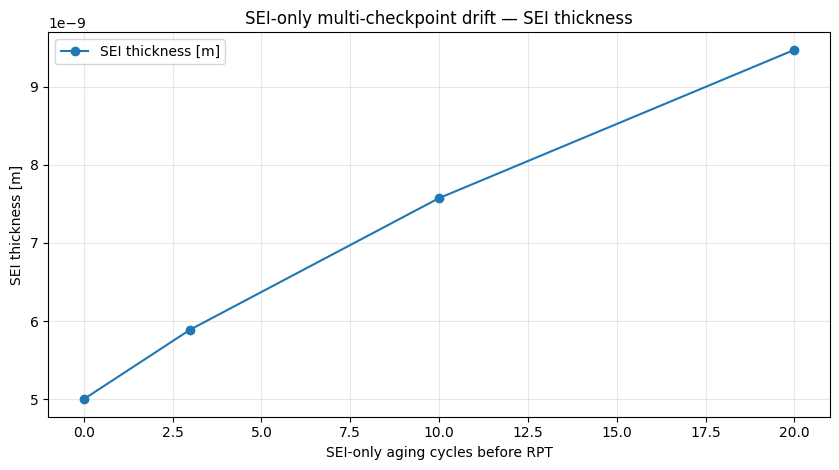

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_multi_checkpoint_sei_thickness_drift.png


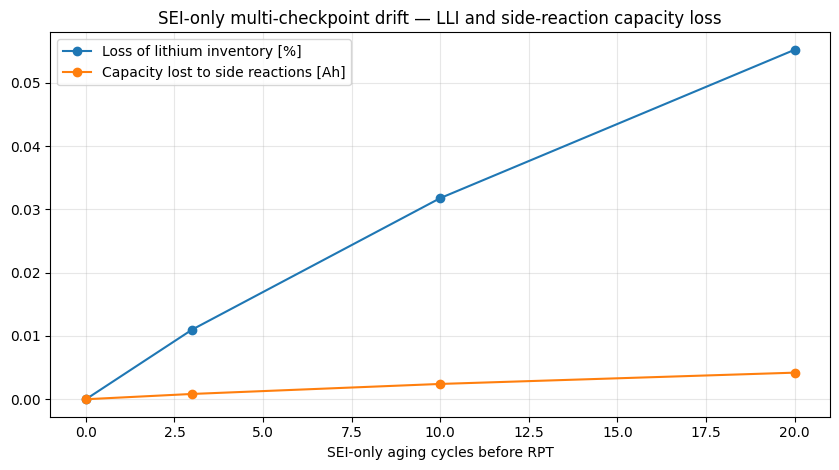

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_multi_checkpoint_LLI_capacity_loss_drift.png


In [12]:
# Cell 12 — Plot degradation-state drift（绘制 SEI / LLI / side-reaction capacity loss 随 checkpoint 漂移）

plot_df = fingerprint_drift_table.copy()
plot_df = plot_df.sort_values("checkpoint_cycles")

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["sei_thickness_m"],
    marker="o",
    label="SEI thickness [m]",
)

ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("SEI thickness [m]")
ax.set_title("SEI-only multi-checkpoint drift — SEI thickness")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_multi_checkpoint_sei_thickness_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["loss_lithium_inventory_pct"],
    marker="o",
    label="Loss of lithium inventory [%]",
)

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["capacity_lost_side_reactions_Ah"],
    marker="o",
    label="Capacity lost to side reactions [Ah]",
)

ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_title("SEI-only multi-checkpoint drift — LLI and side-reaction capacity loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_multi_checkpoint_LLI_capacity_loss_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

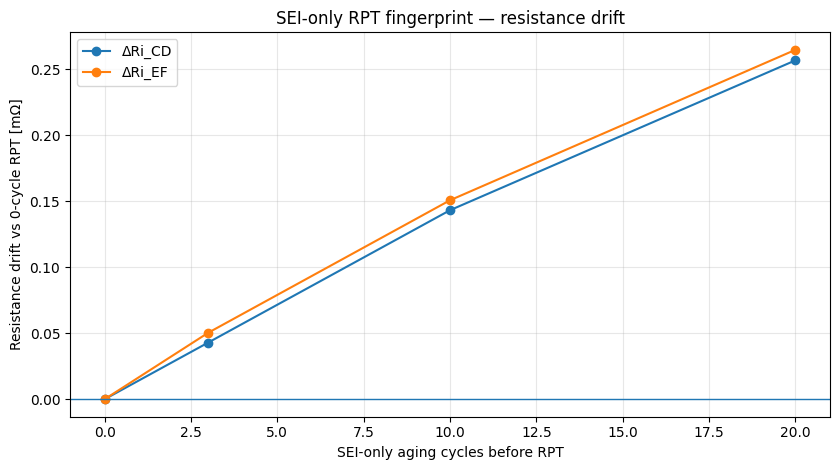

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_multi_checkpoint_Ri_drift.png


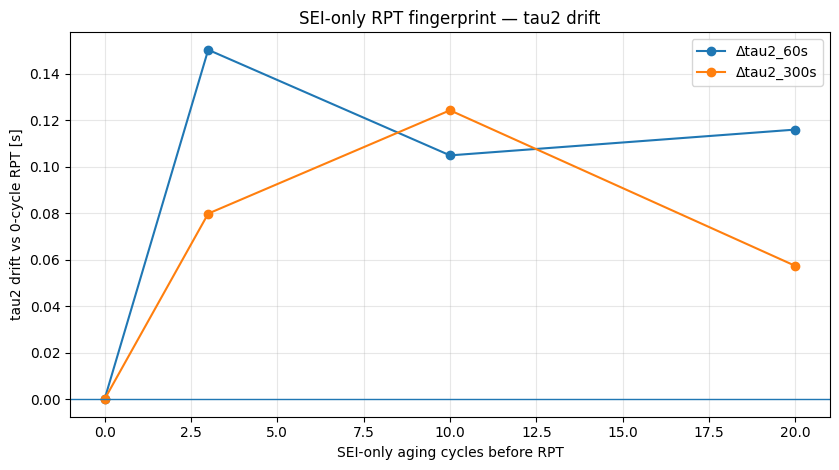

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_multi_checkpoint_tau2_drift.png


In [13]:
# Cell 13 — Plot RPT observable drift（绘制 RPT 提取的 Ri / tau2 漂移）

plot_df = fingerprint_drift_table.copy()
plot_df = plot_df.sort_values("checkpoint_cycles")

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["Ri_CD_mohm_delta_vs_0cycle"],
    marker="o",
    label="ΔRi_CD",
)

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["Ri_EF_mohm_delta_vs_0cycle"],
    marker="o",
    label="ΔRi_EF",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("Resistance drift vs 0-cycle RPT [mΩ]")
ax.set_title("SEI-only RPT fingerprint — resistance drift")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_multi_checkpoint_Ri_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["tau2_60s_delta_vs_0cycle"],
    marker="o",
    label="Δtau2_60s",
)

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["tau2_300s_delta_vs_0cycle"],
    marker="o",
    label="Δtau2_300s",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("tau2 drift vs 0-cycle RPT [s]")
ax.set_title("SEI-only RPT fingerprint — tau2 drift")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_multi_checkpoint_tau2_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [14]:
# Cell 14 — Monotonicity and fingerprint classification audit（单调性与指纹类型审计）

def monotonic_increasing(values, tol=1e-12):
    values = np.asarray(values, dtype=float)
    return bool(np.all(np.diff(values) >= -tol))


audit_metrics = [
    {
        "observable": "sei_thickness_m",
        "category": "degradation_state",
        "values": fingerprint_drift_table.sort_values("checkpoint_cycles")["sei_thickness_m"].values,
        "unit": "m",
    },
    {
        "observable": "loss_lithium_inventory_pct",
        "category": "degradation_state",
        "values": fingerprint_drift_table.sort_values("checkpoint_cycles")["loss_lithium_inventory_pct"].values,
        "unit": "%",
    },
    {
        "observable": "capacity_lost_side_reactions_Ah",
        "category": "degradation_state",
        "values": fingerprint_drift_table.sort_values("checkpoint_cycles")["capacity_lost_side_reactions_Ah"].values,
        "unit": "Ah",
    },
    {
        "observable": "Ri_CD_mohm_delta_vs_0cycle",
        "category": "RPT_observable",
        "values": fingerprint_drift_table.sort_values("checkpoint_cycles")["Ri_CD_mohm_delta_vs_0cycle"].values,
        "unit": "mΩ",
    },
    {
        "observable": "Ri_EF_mohm_delta_vs_0cycle",
        "category": "RPT_observable",
        "values": fingerprint_drift_table.sort_values("checkpoint_cycles")["Ri_EF_mohm_delta_vs_0cycle"].values,
        "unit": "mΩ",
    },
    {
        "observable": "tau2_60s_delta_vs_0cycle",
        "category": "RPT_observable",
        "values": fingerprint_drift_table.sort_values("checkpoint_cycles")["tau2_60s_delta_vs_0cycle"].values,
        "unit": "s",
    },
    {
        "observable": "tau2_300s_delta_vs_0cycle",
        "category": "RPT_observable",
        "values": fingerprint_drift_table.sort_values("checkpoint_cycles")["tau2_300s_delta_vs_0cycle"].values,
        "unit": "s",
    },
]

audit_rows = []

for item in audit_metrics:
    values = item["values"]
    final_delta = values[-1] - values[0]

    audit_rows.append(
        {
            "observable": item["observable"],
            "category": item["category"],
            "unit": item["unit"],
            "start_value": float(values[0]),
            "final_value": float(values[-1]),
            "final_delta": float(final_delta),
            "monotonic_increasing": monotonic_increasing(values),
            "values_by_checkpoint": values.tolist(),
        }
    )

sei_fingerprint_monotonicity_table = pd.DataFrame(audit_rows)

out_csv = DATA / "sei_multi_checkpoint_monotonicity_audit.csv"
sei_fingerprint_monotonicity_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_fingerprint_monotonicity_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_multi_checkpoint_monotonicity_audit.csv


,observable,category,unit,start_value,final_value,final_delta,monotonic_increasing,values_by_checkpoint
0,sei_thickness_m,degradation_state,m,5.000000e-09,9.471973e-09,4.471973e-09,True,"[5.000000000000002e-09, 5.8918182287115225e-09..."
1,loss_lithium_inventory_pct,degradation_state,%,1.421085e-13,5.519954e-02,5.519954e-02,True,"[1.4210854715202004e-13, 0.01100810779320227, ..."
2,capacity_lost_side_reactions_Ah,degradation_state,Ah,0.000000e+00,4.201078e-03,4.201078e-03,True,"[0.0, 0.0008377953848749172, 0.002418115067416..."
3,Ri_CD_mohm_delta_vs_0cycle,RPT_observable,mΩ,0.000000e+00,2.565895e-01,2.565895e-01,True,"[0.0, 0.04292239365017991, 0.14311955686130418..."
4,Ri_EF_mohm_delta_vs_0cycle,RPT_observable,mΩ,0.000000e+00,2.645613e-01,2.645613e-01,True,"[0.0, 0.05034564344006398, 0.15065046567483975..."
5,tau2_60s_delta_vs_0cycle,RPT_observable,s,0.000000e+00,1.159750e-01,1.159750e-01,False,"[0.0, 0.15028443917910295, 0.10487765016179651..."
6,tau2_300s_delta_vs_0cycle,RPT_observable,s,0.000000e+00,5.732569e-02,5.732569e-02,False,"[0.0, 0.07984162003060646, 0.12427037411515585..."


In [19]:
# Cell 19 — Updated SEI-only fingerprint classification table（更新 SEI-only 多 checkpoint 指纹分类表）

final_row = fingerprint_drift_table.sort_values("checkpoint_cycles").iloc[-1]

tau_final = sei_tau_monotonicity_table.copy()

tau1_60_final = tau_final.loc[
    tau_final["observable"] == "tau1_60s_delta_vs_0cycle",
    "final_value",
].iloc[0]

tau1_300_final = tau_final.loc[
    tau_final["observable"] == "tau1_300s_delta_vs_0cycle",
    "final_value",
].iloc[0]

tau2_60_final = tau_final.loc[
    tau_final["observable"] == "tau2_60s_delta_vs_0cycle",
    "final_value",
].iloc[0]

tau2_300_final = tau_final.loc[
    tau_final["observable"] == "tau2_300s_delta_vs_0cycle",
    "final_value",
].iloc[0]

tau_all_monotonic = bool(tau_final["monotonic_increasing"].all())

classification_rows = [
    {
        "fingerprint_layer": "degradation_state",
        "evidence": (
            "SEI thickness, LLI, total lithium lost, and side-reaction capacity loss "
            "increase monotonically across checkpoints"
        ),
        "strength": "strong",
        "interpretation": (
            "SEI-only aging produces a clear capacity/LLI degradation-state signature."
        ),
    },
    {
        "fingerprint_layer": "RPT_Ri",
        "evidence": (
            f"Final ΔRi_CD = {final_row['Ri_CD_mohm_delta_vs_0cycle']:.4f} mΩ; "
            f"Final ΔRi_EF = {final_row['Ri_EF_mohm_delta_vs_0cycle']:.4f} mΩ; "
            "both increase monotonically"
        ),
        "strength": "weak but monotonic",
        "interpretation": (
            "SEI-only aging produces a weak Ri-sensitive diagnostic component."
        ),
    },
    {
        "fingerprint_layer": "RPT_tau",
        "evidence": (
            f"Final Δtau1_60s = {tau1_60_final:.4f} s; "
            f"Final Δtau1_300s = {tau1_300_final:.4f} s; "
            f"Final Δtau2_60s = {tau2_60_final:.4f} s; "
            f"Final Δtau2_300s = {tau2_300_final:.4f} s; "
            f"all_tau_monotonic = {tau_all_monotonic}"
        ),
        "strength": "weak / non-dominant",
        "interpretation": (
            "Fast and slow relaxation descriptors were audited. "
            "Neither tau1 nor tau2 forms the dominant SEI-only fingerprint under this protocol."
        ),
    },
    {
        "fingerprint_layer": "overall_classification",
        "evidence": (
            "Strong degradation-state drift, weak monotonic Ri drift, "
            "and weak non-monotonic tau1/tau2 drift"
        ),
        "strength": "mixed signature",
        "interpretation": (
            "SEI-only aging is primarily capacity/LLI-dominant, "
            "with a weak Ri component and weak non-dominant relaxation-descriptor drift."
        ),
    },
]

sei_fingerprint_classification_table_updated = pd.DataFrame(classification_rows)

out_csv = DATA / "sei_multi_checkpoint_fingerprint_classification_table_updated.csv"
sei_fingerprint_classification_table_updated.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_fingerprint_classification_table_updated)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_multi_checkpoint_fingerprint_classification_table_updated.csv


,fingerprint_layer,evidence,strength,interpretation
0,degradation_state,"SEI thickness, LLI, total lithium lost, and si...",strong,SEI-only aging produces a clear capacity/LLI d...
1,RPT_Ri,Final ΔRi_CD = 0.2566 mΩ; Final ΔRi_EF = 0.264...,weak but monotonic,SEI-only aging produces a weak Ri-sensitive di...
2,RPT_tau,Final Δtau1_60s = -0.0210 s; Final Δtau1_300s ...,weak / non-dominant,Fast and slow relaxation descriptors were audi...
3,overall_classification,"Strong degradation-state drift, weak monotonic...",mixed signature,SEI-only aging is primarily capacity/LLI-domin...


In [16]:
# Cell 16 — Tau1/tau2 drift audit（补充 tau1/tau2 漂移审计）

tau_metrics = [
    "tau1_60s",
    "tau1_300s",
    "tau2_60s",
    "tau2_300s",
]

tau_ref = rpt_observable_table[rpt_observable_table["checkpoint_cycles"] == 0].iloc[0]

tau_rows = []

for _, row in rpt_observable_table.sort_values("checkpoint_cycles").iterrows():
    out = {
        "checkpoint_cycles": row["checkpoint_cycles"],
    }

    for m in tau_metrics:
        val = row[m]
        ref = tau_ref[m]

        out[m] = val
        out[f"{m}_delta_vs_0cycle"] = val - ref

        if abs(ref) > 1e-30:
            out[f"{m}_rel_pct_vs_0cycle"] = 100 * (val - ref) / ref
        else:
            out[f"{m}_rel_pct_vs_0cycle"] = np.nan

    tau_rows.append(out)

sei_multi_checkpoint_tau_drift_table = pd.DataFrame(tau_rows)

out_csv = DATA / "sei_multi_checkpoint_tau1_tau2_drift_table.csv"
sei_multi_checkpoint_tau_drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_multi_checkpoint_tau_drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_multi_checkpoint_tau1_tau2_drift_table.csv


,checkpoint_cycles,tau1_60s,tau1_60s_delta_vs_0cycle,tau1_60s_rel_pct_vs_0cycle,tau1_300s,tau1_300s_delta_vs_0cycle,tau1_300s_rel_pct_vs_0cycle,tau2_60s,tau2_60s_delta_vs_0cycle,tau2_60s_rel_pct_vs_0cycle,tau2_300s,tau2_300s_delta_vs_0cycle,tau2_300s_rel_pct_vs_0cycle
0,0,10.797266,0.000000,0.000000,20.228170,0.000000,0.000000,105.032430,0.000000,0.000000,182.730187,0.000000,0.000000
1,3,10.829617,0.032351,0.299619,20.284483,0.056313,0.278390,105.182714,0.150284,0.143084,182.810029,0.079842,0.043694
2,10,10.792808,-0.004458,-0.041290,20.242977,0.014807,0.073201,105.137307,0.104878,0.099853,182.854458,0.124270,0.068008
3,20,10.776299,-0.020967,-0.194184,20.190180,-0.037990,-0.187808,105.148405,0.115975,0.110418,182.787513,0.057326,0.031372


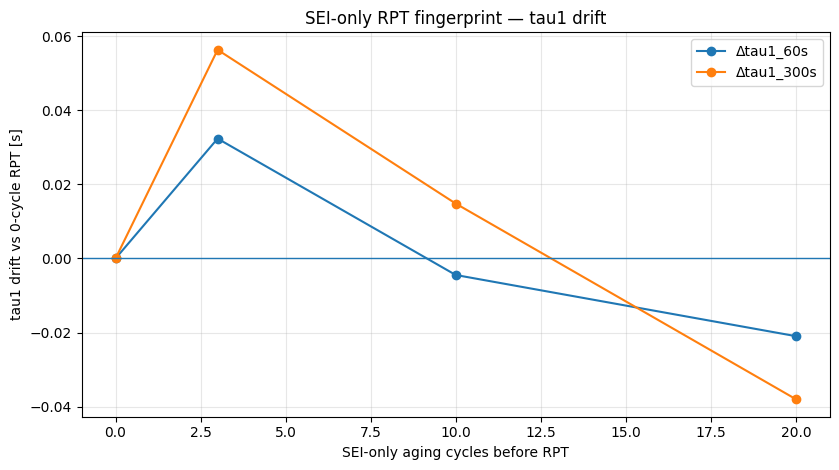

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_multi_checkpoint_tau1_drift.png


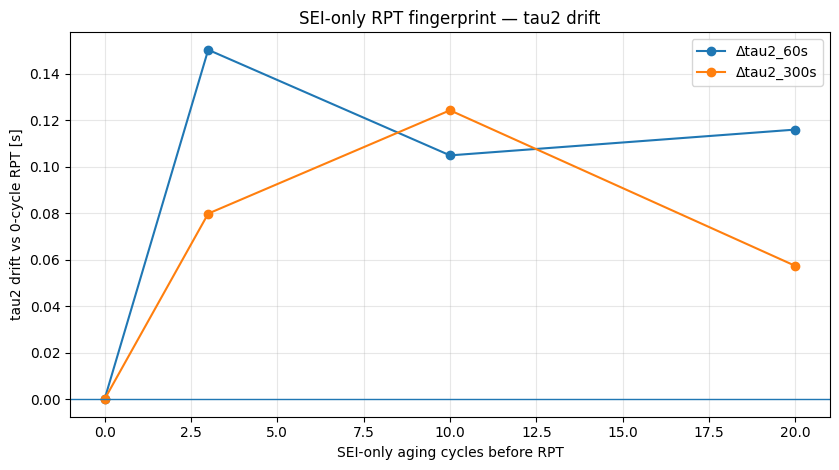

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_multi_checkpoint_tau2_drift_updated.png


In [17]:
# Cell 17 — Plot tau1 and tau2 drift（绘制 tau1/tau2 漂移）

plot_df = sei_multi_checkpoint_tau_drift_table.sort_values("checkpoint_cycles").copy()

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["tau1_60s_delta_vs_0cycle"],
    marker="o",
    label="Δtau1_60s",
)

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["tau1_300s_delta_vs_0cycle"],
    marker="o",
    label="Δtau1_300s",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("tau1 drift vs 0-cycle RPT [s]")
ax.set_title("SEI-only RPT fingerprint — tau1 drift")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_multi_checkpoint_tau1_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["tau2_60s_delta_vs_0cycle"],
    marker="o",
    label="Δtau2_60s",
)

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["tau2_300s_delta_vs_0cycle"],
    marker="o",
    label="Δtau2_300s",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("SEI-only aging cycles before RPT")
ax.set_ylabel("tau2 drift vs 0-cycle RPT [s]")
ax.set_title("SEI-only RPT fingerprint — tau2 drift")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "sei_multi_checkpoint_tau2_drift_updated.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [18]:
# Cell 18 — Updated tau monotonicity audit（补充 tau1/tau2 单调性审计）

def monotonic_increasing(values, tol=1e-12):
    values = np.asarray(values, dtype=float)
    return bool(np.all(np.diff(values) >= -tol))


tau_audit_rows = []

for m in [
    "tau1_60s_delta_vs_0cycle",
    "tau1_300s_delta_vs_0cycle",
    "tau2_60s_delta_vs_0cycle",
    "tau2_300s_delta_vs_0cycle",
]:
    values = plot_df[m].values

    tau_audit_rows.append(
        {
            "observable": m,
            "start_value": float(values[0]),
            "final_value": float(values[-1]),
            "final_delta": float(values[-1] - values[0]),
            "monotonic_increasing": monotonic_increasing(values),
            "values_by_checkpoint": values.tolist(),
        }
    )

sei_tau_monotonicity_table = pd.DataFrame(tau_audit_rows)

out_csv = DATA / "sei_multi_checkpoint_tau_monotonicity_audit.csv"
sei_tau_monotonicity_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_tau_monotonicity_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_multi_checkpoint_tau_monotonicity_audit.csv


,observable,start_value,final_value,final_delta,monotonic_increasing,values_by_checkpoint
0,tau1_60s_delta_vs_0cycle,0.0,-0.020967,-0.020967,False,"[0.0, 0.03235065244997237, -0.0044581577010180..."
1,tau1_300s_delta_vs_0cycle,0.0,-0.037990,-0.037990,False,"[0.0, 0.056313148655494416, 0.0148072110256016..."
2,tau2_60s_delta_vs_0cycle,0.0,0.115975,0.115975,False,"[0.0, 0.15028443917910295, 0.10487765016179651..."
3,tau2_300s_delta_vs_0cycle,0.0,0.057326,0.057326,False,"[0.0, 0.07984162003060646, 0.12427037411515585..."


# Notebook 14 Conclusion

This notebook performed a multi-checkpoint SEI-only aging + RPT / HPPC fingerprint study.

The tested SEI-only aging checkpoints were:

- 0 cycles
- 3 cycles
- 10 cycles
- 20 cycles

At each checkpoint, a diagnostic RPT / HPPC branch was run using the time-based approximate 50% SOC conditioning strategy established in Notebook 13.

## Key findings

### 1. SEI degradation-state variables increase monotonically

The degradation-state variables show clear monotonic growth with cycling.

Observed trends include:

- SEI thickness increases monotonically.
- Loss of lithium inventory increases monotonically.
- Total lithium lost increases monotonically.
- Capacity lost to side reactions increases monotonically.

At the final 20-cycle checkpoint:

- SEI thickness increased from approximately `5.00e-9 m` to `9.47e-9 m`.
- Loss of lithium inventory reached approximately `0.0552 %`.
- Capacity lost to side reactions reached approximately `0.00420 Ah`.

This confirms that the SEI-only branch produces a strong degradation-state signature.

### 2. RPT-derived Ri shows weak but monotonic drift

The RPT-derived resistance observables increase monotonically with SEI-only cycling.

At the final 20-cycle checkpoint:

- `Ri_CD` increased by approximately `0.2566 mΩ` relative to the 0-cycle RPT.
- `Ri_EF` increased by approximately `0.2646 mΩ` relative to the 0-cycle RPT.

The magnitude is small, but the direction is consistent.

This supports a weak Ri-sensitive diagnostic component.

### 3. tau1/tau2 descriptors do not form the dominant SEI-only fingerprint

Both fast and slow relaxation descriptors were audited.

The tau1 descriptors show weak, non-monotonic drift and end slightly below the 0-cycle reference:

- `tau1_60s` final drift was approximately `-0.021 s`.
- `tau1_300s` final drift was approximately `-0.038 s`.

The tau2 descriptors show weak positive final drift, but the checkpoint trend is also non-monotonic:

- `tau2_60s` final drift was approximately `+0.116 s`.
- `tau2_300s` final drift was approximately `+0.057 s`.

Therefore, neither tau1 nor tau2 forms the dominant SEI-only aging fingerprint under this short proof-of-concept protocol.

### 4. Overall fingerprint classification

The SEI-only aging branch produces a mixed observable signature:

- strong degradation-state drift,
- weak but monotonic Ri drift,
- weak and non-dominant tau1/tau2 drift.

The dominant fingerprint layer is:

`capacity / LLI degradation-state signature`

with a secondary:

`weak Ri-sensitive component`

The current result does not support a tau-dominant SEI-only fingerprint.

## Methodological note

The RPT / HPPC branch is diagnostic only.

It is not used as the starting state for subsequent aging. The aging trajectory continues only from the pre-RPT aging state.

This avoids contaminating the aging trajectory with diagnostic RPT perturbations.

## Metric registry update

The current Ri and tau1/tau2 audit is sufficient for this proof-of-concept notebook, but future SEI-only fingerprint analysis should use a broader aging diagnostic metric registry.

The next-stage metric registry should include:

- capacity RPT metrics,
- multi-window resistance metrics,
- fitted tau1/tau2 descriptors,
- non-parametric relaxation descriptors,
- voltage-curve / OCV features where protocol-supported,
- thermal indicators only after a non-isothermal thermal model branch is activated.

## Interpretation boundary

This notebook does not establish a validated SEI aging law or real-cell SOH trajectory.

The cycling protocol is a proof-of-concept simulation protocol.

The RPT conditioning is nominal-capacity based and approximate, not a strict aged-cell true-SOC control.

The correct conclusion is:

Under this SEI-only proof-of-concept protocol, SEI-only aging primarily projects into capacity / LLI degradation-state variables, with weak but monotonic Ri drift and weak non-dominant tau1/tau2 drift.

## Next step

The next notebook should be:

`15_sei_only_capacity_rpt_extension.ipynb`

The purpose should be to extend the SEI-only fingerprint audit by adding:

- external capacity RPT,
- multi-window Ri metrics,
- non-parametric relaxation descriptors such as `tau_FG_eff`, `t95`, `t99`, and `tau_tail`,
- voltage-curve / OCV feature feasibility audit.

The key question will be:

Can the SEI-only fingerprint be closed not only through internal degradation variables, but also through externally observable capacity and voltage-response metrics?